<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

РСА та кареляція даних, Чуркін Дмитро ФІТ 3-15

Був присутній на парі

Завдання. Для датасета "Експресія генів лейкемії" провести EDA, застосувати РСА і побудувати модель класифікації, оцінити, зробити висновки.

Відкрито zip
Файли: ['.config', 'Leukemia_GSE9476.csv', 'Leukemia_GSE9476.csv.zip', 'sample_data']
Використовуємо: Leukemia_GSE9476.csv

Перші строки:
   samples              type  1007_s_at   1053_at     117_at    121_at  \
0        1  Bone_Marrow_CD34   7.745245  7.811210   6.477916  8.841506   
1       12  Bone_Marrow_CD34   8.087252  7.240673   8.584648  8.983571   
2       13  Bone_Marrow_CD34   7.792056  7.549368  11.053504  8.909703   
3       14  Bone_Marrow_CD34   7.767265  7.094460  11.816433  8.994654   
4       15  Bone_Marrow_CD34   8.010117  7.405281   6.656049  9.050682   

   1255_g_at   1294_at   1316_at   1320_at  ...  AFFX-r2-Hs28SrRNA-5_at  \
0   4.546941  7.957714  5.344999  4.673364  ...                5.058849   
1   4.548934  8.011652  5.579647  4.828184  ...                4.436153   
2   4.549328  8.237099  5.406489  4.615572  ...                4.392061   
3   4.697018  8.283412  5.582195  4.903684  ...                4.633334   
4   4.514986  8.377046  5.493

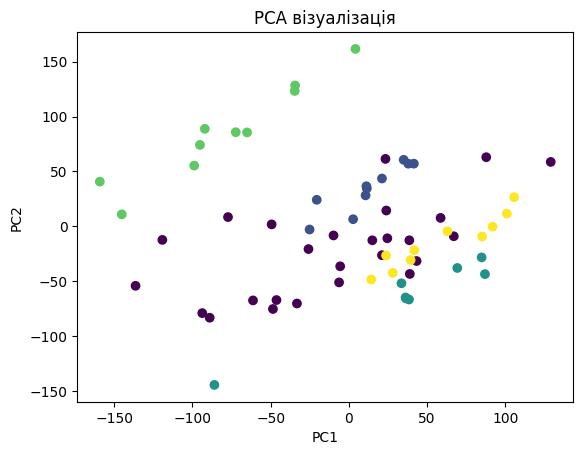


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         3

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [5]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

import zipfile

with zipfile.ZipFile("Leukemia_GSE9476.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Відкрито")

# 1. Завантаження даних
print("Файли:", os.listdir())

file_name = [f for f in os.listdir() if f.endswith(".csv")][0]
print("Використовуємо:", file_name)

df = pd.read_csv(file_name)

print("\nПерші строки:")
print(df.head())

# 2. EDA
print("\nІнформація:")
print(df.info())

df = df.drop(columns=[df.columns[0]])

print("\nПропуски:")
print(df.isnull().sum())

df = df.dropna()

print("\nДублікати:", df.duplicated().sum())
df = df.drop_duplicates()

# 3. Визначення target
target_col = None
for col in df.columns:
    if df[col].dtype == 'object':
        target_col = col
        break

if target_col is None:
    target_col = df.columns[-1]

print("\nTarget:", target_col)

X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Кодування target
le = LabelEncoder()
y = le.fit_transform(y)

X = X.select_dtypes(include=['number'])

# 5. Масштабування
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nЧастка поясненої дисперсії:")
print(pca.explained_variance_ratio_)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("PCA візуалізація")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 7. Поділ даних
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 8. Модель
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 9. Оцінка
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Висновок

У ході виконання лабораторної роботи було проведено аналіз датасету експресії генів лейкемії. На етапі попереднього аналізу даних (EDA) було досліджено структуру датасету, перевірено наявність пропущених значень та дублікатів, які були усунені.

Для зменшення розмірності даних застосовано метод головних компонент (PCA), що дозволило представити високовимірні дані у двовимірному просторі. Візуалізація показала наявність певного розділення між класами, що свідчить про можливість ефективної класифікації.

Було побудовано модель класифікації на основі алгоритму Random Forest. За результатами оцінювання модель продемонструвала достатньо високу точність, що підтверджується значенням метрики accuracy та показниками precision, recall і F1-score.